## **Interpretação do Modelo e Análise de Negócio — Fraude em Cartão de Crédito**

Neste notebook traduzi os resultados técnicos em **impacto de negócio**: quanto dinheiro o modelo economiza, qual o custo dos erros e como calibrar o threshold conforme a tolerância ao risco do banco.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import joblib
from sklearn.metrics import (
    precision_recall_curve, confusion_matrix,
    fbeta_score, recall_score, precision_score
)
import warnings
warnings.filterwarnings('ignore')

DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../figures')
MODELS_DIR  = Path('../models')

COR_FRAUDE = '#E74C3C'
COR_LEGIT  = '#2ECC71'
COR_ACCENT = '#2980B9'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})

def save_fig(name):
    path = FIGURES_DIR / f'{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Salvo: {path}')
    plt.show()
    plt.close()

In [3]:
# Carregar dados e modelo
df = pd.read_csv(DATA_DIR / 'creditcard.csv')

# Recriar features de engenharia
df['Amount_Log']      = np.log1p(df['Amount'])
df['Time_Seconds_Day']= df['Time'] % 86400
df['Time_Hour_Sin']   = np.sin(2 * np.pi * df['Time_Seconds_Day'] / 86400)
df['Time_Hour_Cos']   = np.cos(2 * np.pi * df['Time_Seconds_Day'] / 86400)

FEATURES = joblib.load(MODELS_DIR / 'features.pkl')
scaler   = joblib.load(MODELS_DIR / 'scaler.pkl')
modelo   = joblib.load(MODELS_DIR / 'modelo_final.pkl')
thr_otimo= joblib.load(MODELS_DIR / 'threshold_final.pkl')

# Separar teste (mesmo split temporal do notebook 02)
df = df.sort_values('Time').reset_index(drop=True)
cutoff   = df['Time'].quantile(0.80)
df_test  = df[df['Time'] > cutoff].copy()
X_test   = pd.DataFrame(scaler.transform(df_test[FEATURES]), columns=FEATURES)
y_test   = df_test['Class']

y_proba  = modelo.predict_proba(X_test)[:, 1]
y_pred   = (y_proba >= thr_otimo).astype(int)

print(f'Modelo carregado | Threshold: {thr_otimo:.4f}')
print(f'Conjunto de teste: {len(y_test):,} transações | {y_test.sum()} fraudes')

Modelo carregado | Threshold: 0.5475
Conjunto de teste: 56,962 transações | 75 fraudes


## **Análise do Impacto Financeiro:**

In [4]:
cm  = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Valor médio das transações fraudulentas no conjunto de teste
amount_fraudes = df_test[df_test['Class'] == 1]['Amount']
valor_medio_fraude = amount_fraudes.mean()
valor_total_fraude = amount_fraudes.sum()

# Impacto financeiro
valor_detectado  = df_test[df_test['Class'] == 1]['Amount'].iloc[:tp].sum()  # aproximação
valor_perdido_fn = fn * valor_medio_fraude  # fraudes não detectadas
custo_fp         = fp * 2.0                 # custo estimado de revisão manual por transação ($2)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║                  ANÁLISE DE IMPACTO FINANCEIRO               ║
╠══════════════════════════════════════════════════════════════╣
║  Conjunto de teste                                           ║
║   Total de transações  : {len(y_test):>10,}                    ║
║   Fraudes reais        : {int(y_test.sum()):>10,}                    ║
║   Valor total em fraude: ${valor_total_fraude:>10,.2f}                ║
║   Valor médio da fraude: ${valor_medio_fraude:>10,.2f}                ║
╠══════════════════════════════════════════════════════════════╣
║  Resultado do modelo                                         ║
║   Fraudes detectadas (TP) : {tp:>6}                          ║
║   Fraudes perdidas (FN)   : {fn:>6}  ← prejuízo direto       ║
║   Legítimas bloqueadas(FP): {fp:>6,}                         ║
╠══════════════════════════════════════════════════════════════╣
║  Estimativa de impacto                                       ║
║   Valor perdido (FN × média): ${valor_perdido_fn:>9,.2f}           ║
║   Custo revisão manual (FP) : ${custo_fp:>9,.2f}           ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║                  ANÁLISE DE IMPACTO FINANCEIRO               ║
╠══════════════════════════════════════════════════════════════╣
║  Conjunto de teste                                           ║
║   Total de transações  :     56,962                    ║
║   Fraudes reais        :         75                    ║
║   Valor total em fraude: $  7,729.26                ║
║   Valor médio da fraude: $    103.06                ║
╠══════════════════════════════════════════════════════════════╣
║  Resultado do modelo                                         ║
║   Fraudes detectadas (TP) :     57                          ║
║   Fraudes perdidas (FN)   :     18  ← prejuízo direto       ║
║   Legítimas bloqueadas(FP):      8                         ║
╠══════════════════════════════════════════════════════════════╣
║  Estimativa de impacto                                       ║
║   Valor perdido (FN × média): $ 1,855.02           ║
║  

## **Curva de Threshold vs Métricas de Negócio:**

A escolha do threshold é uma decisão de negócio: abaixar o threshold aumenta o recall (menos fraudes escapam) mas aumenta os falsos positivos (mais clientes legítimos bloqueados).

Salvo: ..\figures\12_curvas_threshold.png


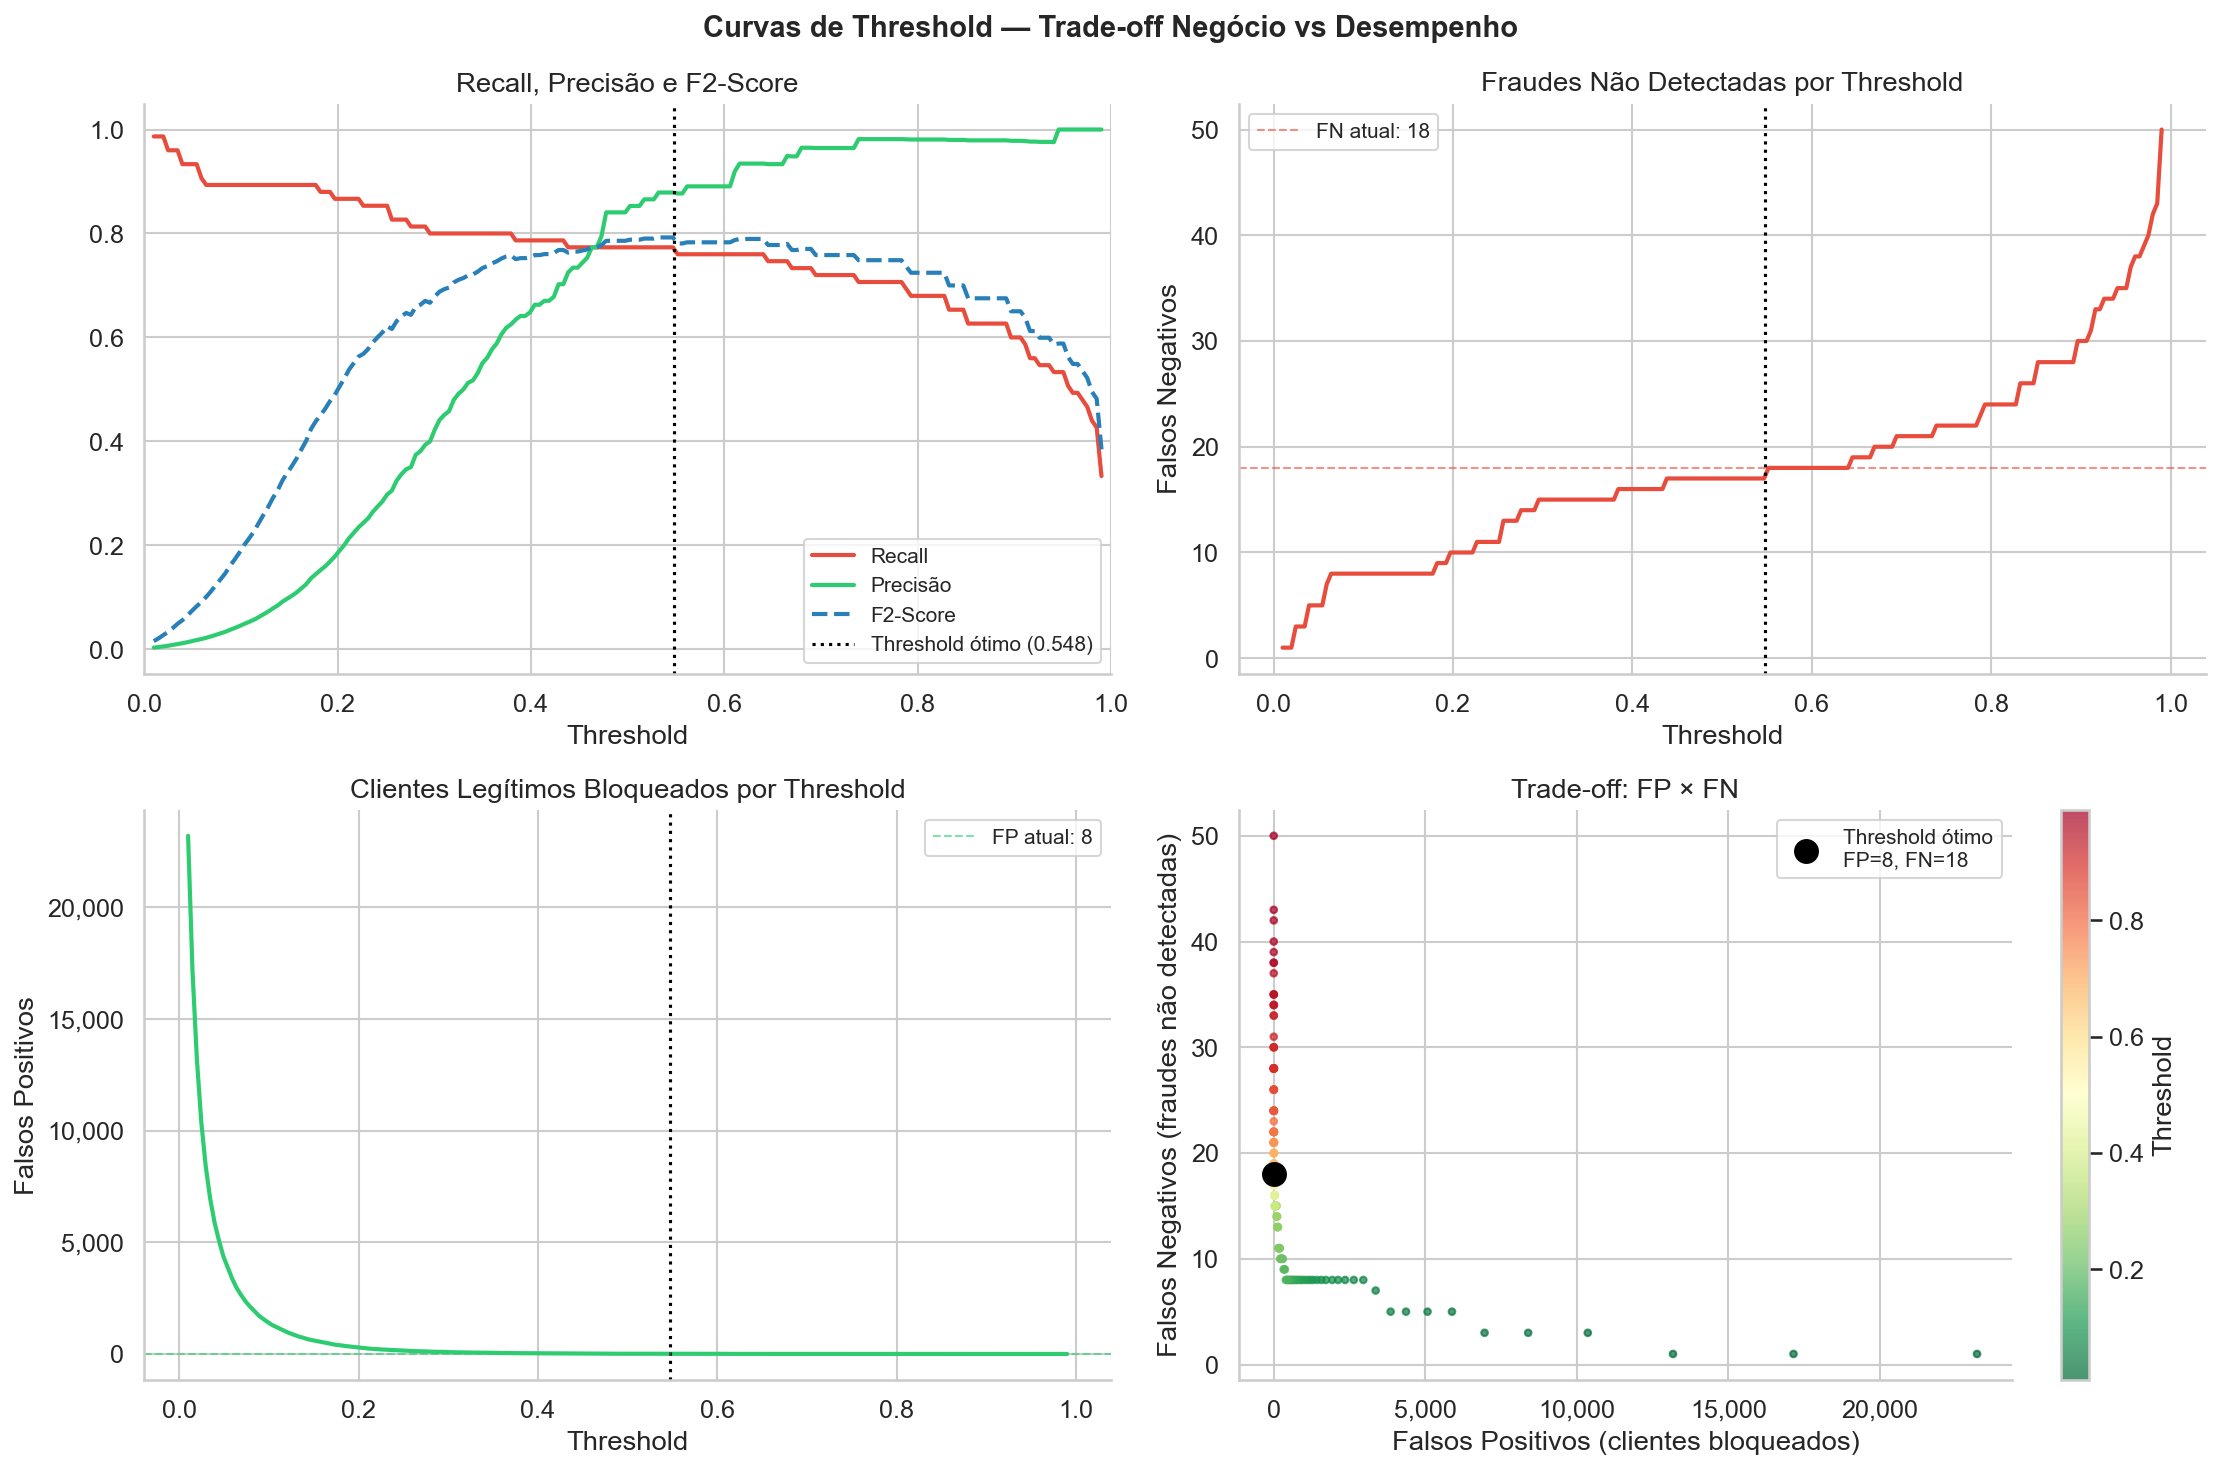

In [5]:
thresholds = np.linspace(0.01, 0.99, 200)
recalls, precisoes, f2s, fps_list, fns_list = [], [], [], [], []

for thr in thresholds:
    ypred_t = (y_proba >= thr).astype(int)
    cm_t    = confusion_matrix(y_test, ypred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

    recalls.append(recall_score(y_test, ypred_t, zero_division=0))
    precisoes.append(precision_score(y_test, ypred_t, zero_division=0))
    f2s.append(fbeta_score(y_test, ypred_t, beta=2, zero_division=0))
    fps_list.append(fp_t)
    fns_list.append(fn_t)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Curvas de Threshold — Trade-off Negócio vs Desempenho',
             fontsize=14, fontweight='bold')

# Recall × Precisão
ax = axes[0, 0]
ax.plot(thresholds, recalls,   color=COR_FRAUDE, linewidth=2, label='Recall')
ax.plot(thresholds, precisoes, color=COR_LEGIT,  linewidth=2, label='Precisão')
ax.plot(thresholds, f2s,       color=COR_ACCENT, linewidth=2, label='F2-Score', linestyle='--')
ax.axvline(thr_otimo, color='black', linestyle=':', linewidth=1.5,
           label=f'Threshold ótimo ({thr_otimo:.3f})')
ax.set_xlabel('Threshold')
ax.set_title('Recall, Precisão e F2-Score')
ax.legend(fontsize=10)
ax.set_xlim([0, 1])

# Falsos Negativos
ax = axes[0, 1]
ax.plot(thresholds, fns_list, color=COR_FRAUDE, linewidth=2)
ax.axvline(thr_otimo, color='black', linestyle=':', linewidth=1.5)
ax.axhline(fn, color=COR_FRAUDE, linestyle='--', linewidth=1, alpha=0.6,
           label=f'FN atual: {fn}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Falsos Negativos')
ax.set_title('Fraudes Não Detectadas por Threshold')
ax.legend(fontsize=10)

# Falsos Positivos
ax = axes[1, 0]
ax.plot(thresholds, fps_list, color=COR_LEGIT, linewidth=2)
ax.axvline(thr_otimo, color='black', linestyle=':', linewidth=1.5)
ax.axhline(fp, color=COR_LEGIT, linestyle='--', linewidth=1, alpha=0.6,
           label=f'FP atual: {fp:,}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Falsos Positivos')
ax.set_title('Clientes Legítimos Bloqueados por Threshold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)

# Trade-off FN × FP
ax = axes[1, 1]
sc = ax.scatter(fps_list, fns_list, c=thresholds,
                cmap='RdYlGn_r', s=10, alpha=0.7)
ax.scatter(fp, fn, color='black', s=120, zorder=5,
           label=f'Threshold ótimo\nFP={fp:,}, FN={fn}')
plt.colorbar(sc, ax=ax, label='Threshold')
ax.set_xlabel('Falsos Positivos (clientes bloqueados)')
ax.set_ylabel('Falsos Negativos (fraudes não detectadas)')
ax.set_title('Trade-off: FP × FN')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
save_fig('12_curvas_threshold')

## **Distribuição dos Scores de Risco:**

Salvo: ..\figures\13_distribuicao_scores.png


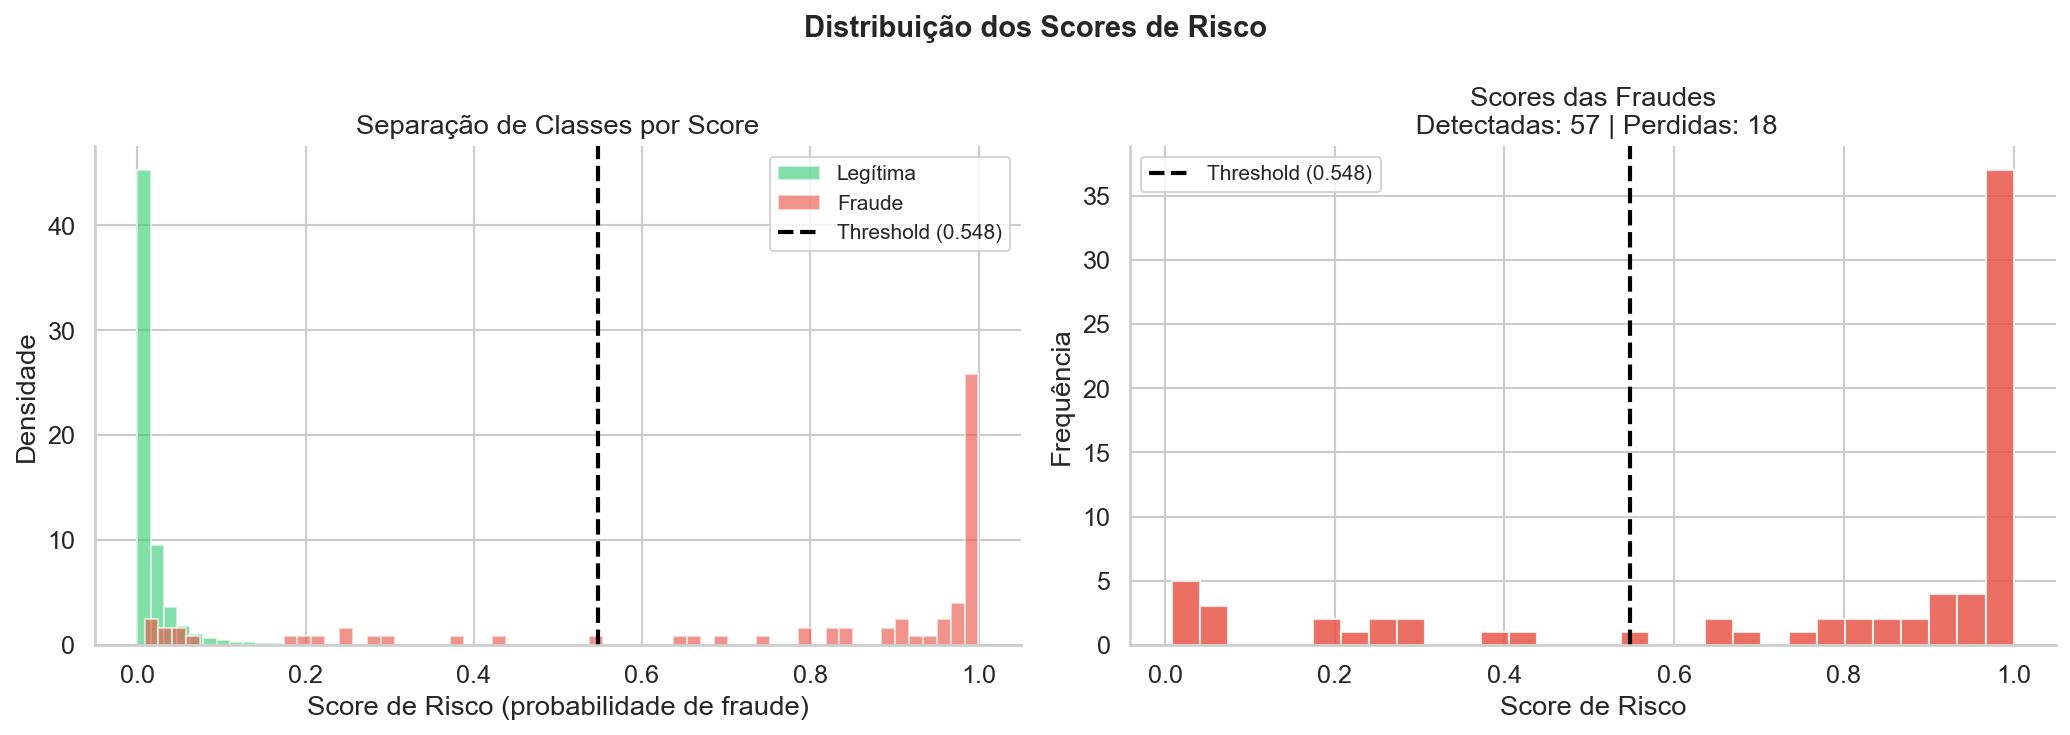

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição dos Scores de Risco', fontsize=14, fontweight='bold')

# Histograma
ax = axes[0]
ax.hist(y_proba[y_test == 0], bins=60, alpha=0.6, color=COR_LEGIT,
        label='Legítima', density=True)
ax.hist(y_proba[y_test == 1], bins=60, alpha=0.6, color=COR_FRAUDE,
        label='Fraude', density=True)
ax.axvline(thr_otimo, color='black', linestyle='--', linewidth=2,
           label=f'Threshold ({thr_otimo:.3f})')
ax.set_xlabel('Score de Risco (probabilidade de fraude)')
ax.set_ylabel('Densidade')
ax.set_title('Separação de Classes por Score')
ax.legend(fontsize=10)

# Zoom nas fraudes
ax = axes[1]
ax.hist(y_proba[y_test == 1], bins=30, color=COR_FRAUDE,
        alpha=0.8, edgecolor='white')
ax.axvline(thr_otimo, color='black', linestyle='--', linewidth=2,
           label=f'Threshold ({thr_otimo:.3f})')
n_acima = (y_proba[y_test == 1] >= thr_otimo).sum()
n_abaixo = (y_proba[y_test == 1] < thr_otimo).sum()
ax.set_xlabel('Score de Risco')
ax.set_ylabel('Frequência')
ax.set_title(f'Scores das Fraudes\n Detectadas: {n_acima} | Perdidas: {n_abaixo}')
ax.legend(fontsize=10)

plt.tight_layout()
save_fig('13_distribuicao_scores')

## **Limitações e Próximos Passos:**

In [9]:
rec  = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
from sklearn.metrics import roc_auc_score, average_precision_score
auc    = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
f2     = fbeta_score(y_test, y_pred, beta=2)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║               RESULTADO FINAL DO PROJETO                     ║
╠══════════════════════════════════════════════════════════════╣
║  Recall    : {rec:.4f}  - % de fraudes detectadas              ║
║  Precisão  : {prec:.4f}                                        ║
║  F2-Score  : {f2:.4f}                                        ║
║  AUC-ROC   : {auc:.4f}                                        ║
║  PR-AUC    : {pr_auc:.4f}                                        ║
║  FN        : {fn} fraudes não detectadas                      ║
║  FP        : {fp:,} legítimas bloqueadas                     ║
╠══════════════════════════════════════════════════════════════╣
║  LIMITAÇÕES                                                  ║
║  • Features V1–V28 são PCA anônimos — não interpretáveis     ║
║  • Dataset cobre apenas 2 dias — possível drift temporal      ║
║  • Custo dos erros estimado — valores reais variam           ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║               RESULTADO FINAL DO PROJETO                     ║
╠══════════════════════════════════════════════════════════════╣
║  Recall    : 0.7600  - % de fraudes detectadas              ║
║  Precisão  : 0.8769                                        ║
║  F2-Score  : 0.7808                                        ║
║  AUC-ROC   : 0.9825                                        ║
║  PR-AUC    : 0.8107                                        ║
║  FN        : 18 fraudes não detectadas                      ║
║  FP        : 8 legítimas bloqueadas                     ║
╠══════════════════════════════════════════════════════════════╣
║  LIMITAÇÕES                                                  ║
║  • Features V1–V28 são PCA anônimos — não interpretáveis     ║
║  • Dataset cobre apenas 2 dias — possível drift temporal      ║
║  • Custo dos erros estimado — valores reais variam           ║
╚═════════════════════════════════════